# Bivariate Analysis

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('../../data/processed/final_dataset_clean.csv')

## Gender vs Weight-for-Age Z-Score

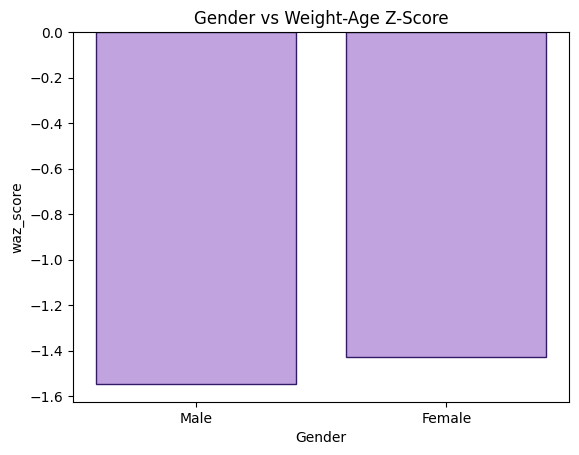

In [2]:
means = df.groupby('child_sex')['waz_score'].mean()

color = (0.6, # redness
         0.4, # greenness
         0.8, # blueness
         0.6  # transparency
         )

edge_color = (0.2, # redness
              0.1, # greenness
              0.4, # blueness
              1  # transparency
              )

plt.bar(means.index, means.values, color=color, edgecolor=edge_color)
plt.title('Gender vs Weight-Age Z-Score')
plt.xticks(means.index, ['Male', 'Female'])
plt.xlabel("Gender")
plt.ylabel("waz_score")
# plt.savefig('screenshots/ss_bivariate/gender_waz_bivariate_bar.png')
plt.show()

## Height for Age vs Weight for Age (Z-Score)

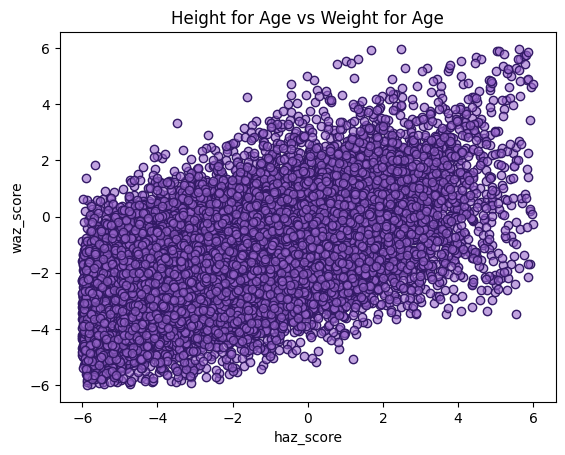

In [3]:
x = df['haz_score']
y = df['waz_score']

plt.scatter(x, y, color=color, edgecolor=edge_color)
plt.title('Height for Age vs Weight for Age')
plt.xlabel("haz_score")
plt.ylabel("waz_score")
# plt.savefig('screenshots/ss_bivariate/haz_waz_bivariate_scatter.png')
plt.show()

## Age vs HAZ Score

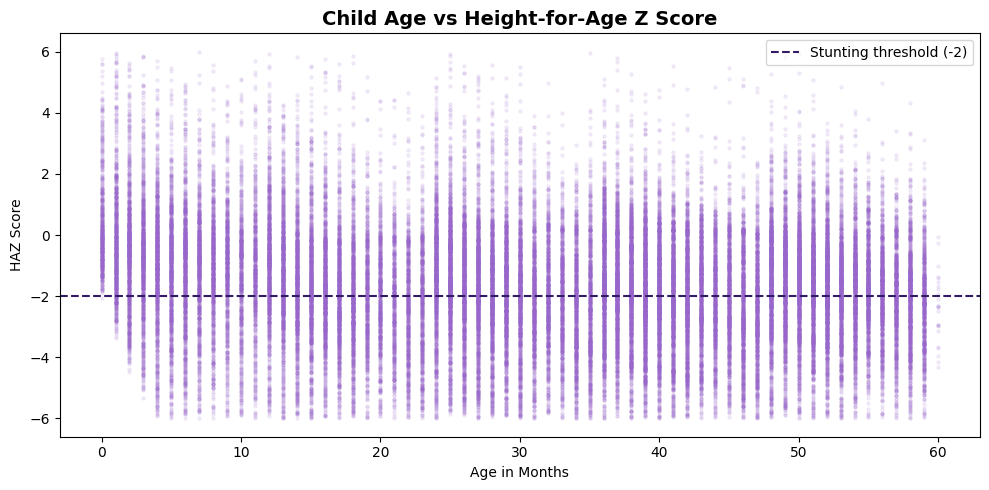

In [4]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.scatter(df['child_age_months'], df['haz_score'],
           alpha=0.1, color=color, s=5)
ax.axhline(y=-2, color=edge_color, linestyle='--', linewidth=1.5, label='Stunting threshold (-2)')
ax.set_title('Child Age vs Height-for-Age Z Score', fontsize=14, fontweight='bold')
ax.set_xlabel('Age in Months')
ax.set_ylabel('HAZ Score')
ax.legend()
plt.tight_layout()
plt.savefig("screenshots/ss_bivariate/age_haz_bivariate_scatter.png")
plt.show()

## Breastfeeding vs Weight-for-Age Z-Score

In [5]:
df['breastfeeding'].value_counts()
# note: Replace 9.0 with NaN before training model

breastfeeding
2.0    56273
1.0     4317
9.0      460
Name: count, dtype: int64

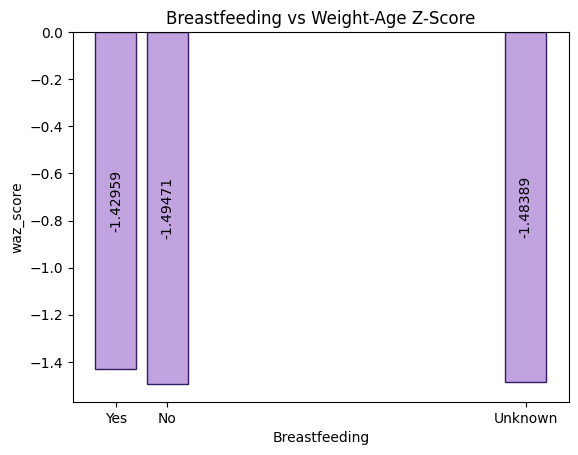

In [6]:
means = df.groupby('breastfeeding')['waz_score'].mean()

bars = plt.bar(means.index, means.values, color=color, edgecolor=edge_color)
plt.title('Breastfeeding vs Weight-Age Z-Score')
plt.xticks(means.index, ['Yes', 'No', 'Unknown'])
plt.xlabel("Breastfeeding")
plt.ylabel("waz_score")
plt.bar_label(bars, label_type='center', rotation=90)
# plt.savefig('screenshots/ss_bivariate/breastfeeding_waz_bivariate_bar.png')
plt.show()



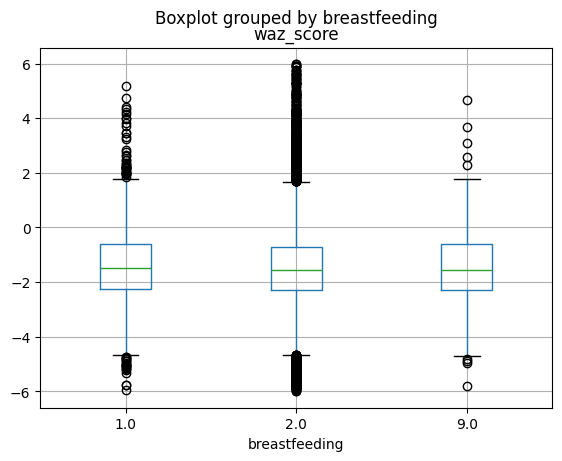

In [7]:
df.boxplot(column='waz_score', by='breastfeeding')
# plt.savefig('screenshots/ss_bivariate/breastfeeding_waz_bivariate_box.png')
plt.show()

## Mother's Educaiton vs Underweight

In [8]:
df['underweight'].value_counts()

underweight
0    43063
1    17987
Name: count, dtype: int64

<Figure size 640x480 with 0 Axes>

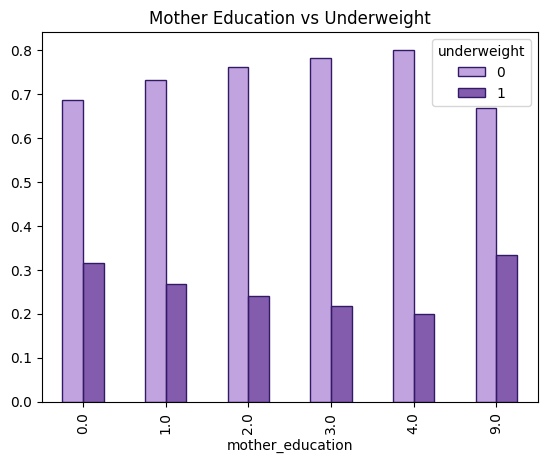

In [9]:
ct = pd.crosstab(df['mother_education'], df['underweight'], normalize='index')

dark_purple = (0.4, # redness
                0.2, # greenness
                0.6, # blueness
                0.8  # transparency
                )
plt.savefig('screenshots/ss_bivariate/mother_education_undeweight_bivariate_grouped.png')
ct.plot(kind='bar', color=[color, dark_purple], edgecolor=edge_color)
plt.title('Mother Education vs Underweight')
plt.show()

## urban_rural vs Underweight

In [10]:
df['urban_rural'].value_counts()

urban_rural
1    46768
0    14282
Name: count, dtype: int64

<Figure size 640x480 with 0 Axes>

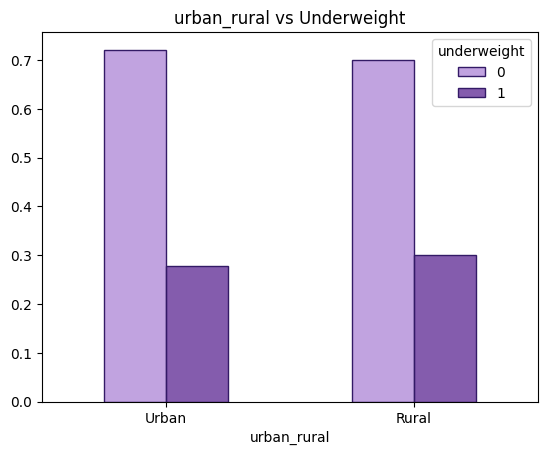

In [11]:
ct = pd.crosstab(df['urban_rural'], df['underweight'], normalize='index')

dark_purple =  (0.4, # redness
                0.2, # greenness
                0.6, # blueness
                0.8  # transparency
                )
plt.savefig('screenshots/ss_bivariate/urban_rural_undeweight_bivariate_grouped.png')
ct.plot(kind='bar', color=[color, dark_purple], edgecolor=edge_color)
plt.title('urban_rural vs Underweight')
plt.xticks([0, 1], ['Urban', 'Rural'], rotation=360)
plt.show()

## Stunted vs Urban-Rural

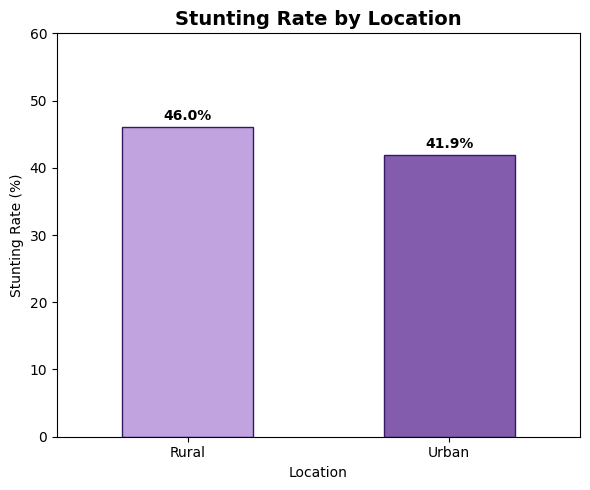

In [12]:
# Stunting rate by Urban vs Rural
fig, ax = plt.subplots(figsize=(6, 5))
location_labels = {0: 'Urban', 1: 'Rural'}
df['location'] = df['urban_rural'].map(location_labels)
location_stunting = df.groupby('location')['stunted'].mean() * 100
colors = [color, dark_purple]
location_stunting.plot(kind='bar', ax=ax, color=colors, edgecolor=edge_color, width=0.5)
ax.set_title('Stunting Rate by Location', fontsize=14, fontweight='bold')
ax.set_xlabel('Location')
ax.set_ylabel('Stunting Rate (%)')
ax.set_ylim(0, 60)
for i, v in enumerate(location_stunting):
    ax.text(i, v + 1, f'{v:.1f}%', ha='center', fontweight='bold')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("screenshots/ss_bivariate/stunting_urban_bivariate_bar.png")
plt.show()

## Stunting vs Province

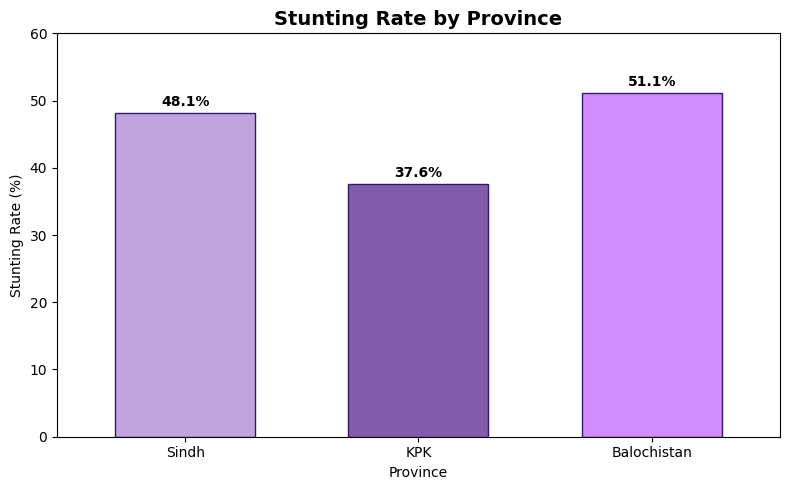

In [13]:
# Stunting rate by Province
also_purple =  (0.8, # redness
                0.5, # greenness
                1, # blueness
                0.9  # transparency
                )

fig, ax = plt.subplots(figsize=(8, 5))
province_stunting = df.groupby('province')['stunted'].mean() * 100
colors = [color, dark_purple, also_purple]
bars = province_stunting.plot(kind='bar', ax=ax, color=colors, edgecolor=edge_color, width=0.6)
ax.set_title('Stunting Rate by Province', fontsize=14, fontweight='bold')
ax.set_xlabel('Province')
ax.set_ylabel('Stunting Rate (%)')
ax.set_ylim(0, 60)
for i, v in enumerate(province_stunting):
    ax.text(i, v + 1, f'{v:.1f}%', ha='center', fontweight='bold')
plt.xticks([0, 1, 2], ['Sindh', 'KPK', 'Balochistan'], rotation=0)
plt.tight_layout()
plt.savefig("screenshots/ss_bivariate_stunting_province_bivariate_bar.png")
plt.show()

## Stunting vs Wealth Index

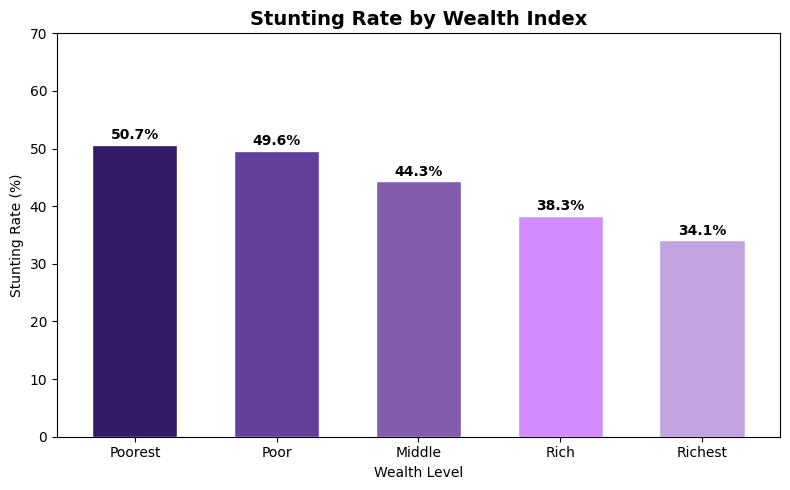

In [32]:
fig, ax = plt.subplots(figsize=(8, 5))
wealth_labels = {1: 'Poorest', 2: 'Poor', 3: 'Middle', 4: 'Rich', 5: 'Richest'}
df['wealth_label'] = df['wealth_index'].map(wealth_labels)
wealth_order = ['Poorest', 'Poor', 'Middle', 'Rich', 'Richest']
wealth_stunting = df.groupby('wealth_label')['stunted'].mean() * 100
wealth_stunting = wealth_stunting.reindex(wealth_order)
colors = [edge_color, '#633f9e', dark_purple, also_purple, color]
wealth_stunting.plot(kind='bar', ax=ax, color=colors, edgecolor='white', width=0.6)
ax.set_title('Stunting Rate by Wealth Index', fontsize=14, fontweight='bold')
ax.set_xlabel('Wealth Level')
ax.set_ylabel('Stunting Rate (%)')
ax.set_ylim(0, 70)
for i, v in enumerate(wealth_stunting):
    ax.text(i, v + 1, f'{v:.1f}%', ha='center', fontweight='bold')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("screenshots/ss_bivariate/stunting_wealth_bivariate_bar.png")
plt.show()

## Stunting vs Mohter's Education

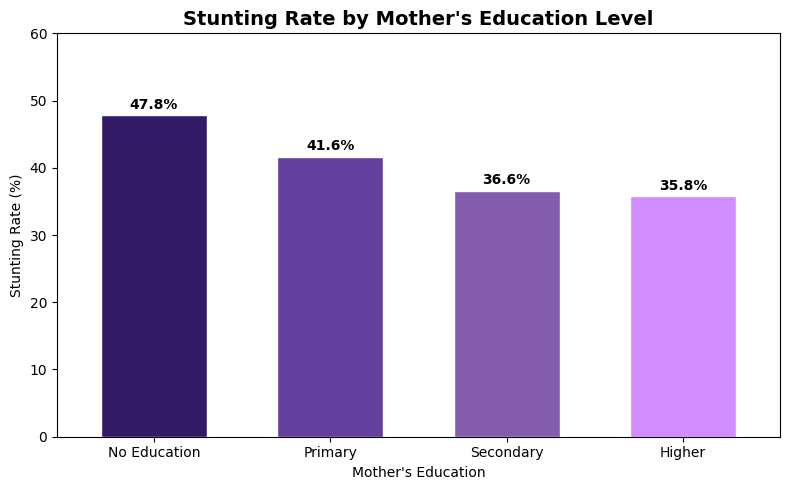

In [34]:
fig, ax = plt.subplots(figsize=(8, 5))
edu_labels = {0: 'No Education', 1: 'Primary', 2: 'Secondary', 3: 'Higher'}
df['edu_label'] = df['mother_education'].map(edu_labels)
edu_order = ['No Education', 'Primary', 'Secondary', 'Higher']
edu_stunting = df.groupby('edu_label')['stunted'].mean() * 100
edu_stunting = edu_stunting.reindex(edu_order)
colors = [edge_color, '#633f9e', dark_purple, also_purple, color]
edu_stunting.plot(kind='bar', ax=ax, color=colors, edgecolor='white', width=0.6)
ax.set_title("Stunting Rate by Mother's Education Level", fontsize=14, fontweight='bold')
ax.set_xlabel("Mother's Education")
ax.set_ylabel('Stunting Rate (%)')
ax.set_ylim(0, 60)
for i, v in enumerate(edu_stunting):
    ax.text(i, v + 1, f'{v:.1f}%', ha='center', fontweight='bold')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("screenshots/ss_bivariate/stunting_education_bivariate_bars.png")
plt.show()

## Wealth Index vs Underweight

In [11]:
df['wealth_index'].value_counts()

wealth_index
1.0    17577
2.0    14199
3.0    11547
4.0     9940
5.0     7787
Name: count, dtype: int64

1 - 5 -> poorest to richest

<Figure size 640x480 with 0 Axes>

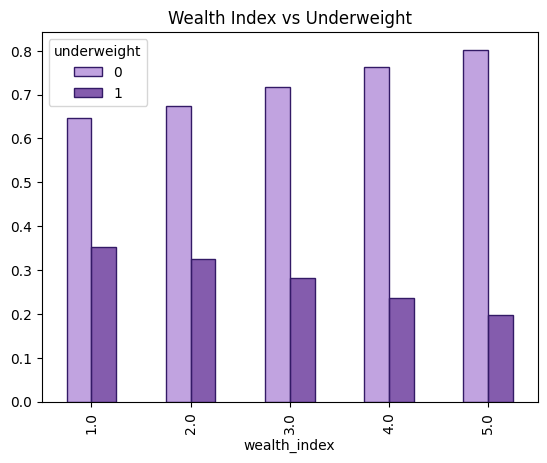

In [12]:
ct = pd.crosstab(df['wealth_index'], df['underweight'], normalize='index')

dark_purple =  (0.4, # redness
                0.2, # greenness
                0.6, # blueness
                0.8  # transparency
                )
plt.savefig('screenshots/ss_bivariate/wealth_undeweight_bivariate_grouped.png')
ct.plot(kind='bar', color=[color, dark_purple], edgecolor=edge_color)
plt.title('Wealth Index vs Underweight')
plt.show()

## Gender vs Stunted, Wasted, Underweight

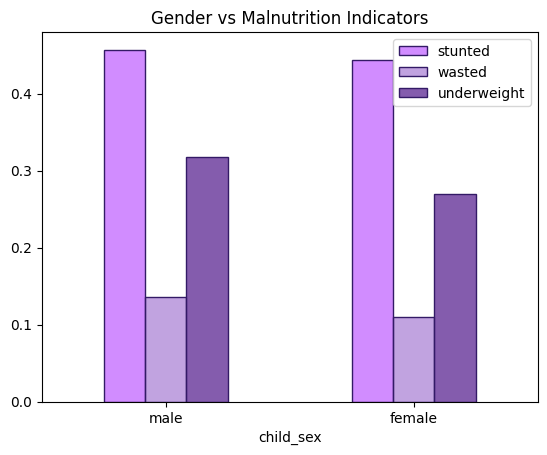

In [28]:
df.groupby('child_sex')[['stunted', 'wasted', 'underweight']].mean().plot(kind='bar', color=[also_purple, color, dark_purple], edgecolor=edge_color)
plt.title('Gender vs Malnutrition Indicators')
plt.savefig('screenshots/ss_bivariate/gender_malnutrition_bivariate_grouped.png')
plt.xticks([0, 1], ['male', 'female'], rotation=360)
plt.show()

## `stunted` vs `waz_score`
Are stunted children also underweight?

In [14]:
df['stunted'].value_counts()

stunted
0    33527
1    27523
Name: count, dtype: int64

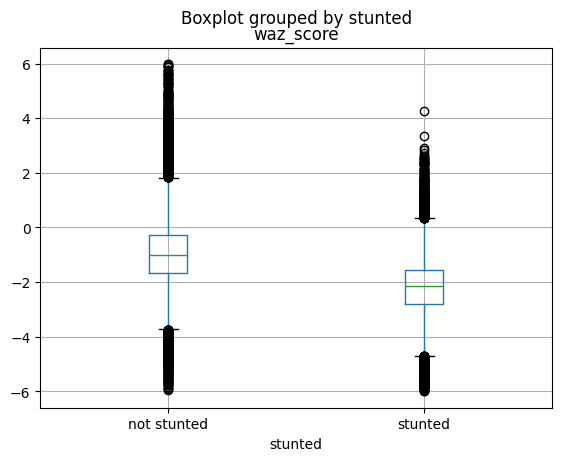

In [15]:
df.boxplot(column='waz_score', by='stunted')
plt.xticks([1, 2], ['not stunted', 'stunted'])
plt.savefig('screenshots/ss_bivariate/stunted_waz_bivariate_box.png')
plt.show()

## `waz_score` vs `underweight`

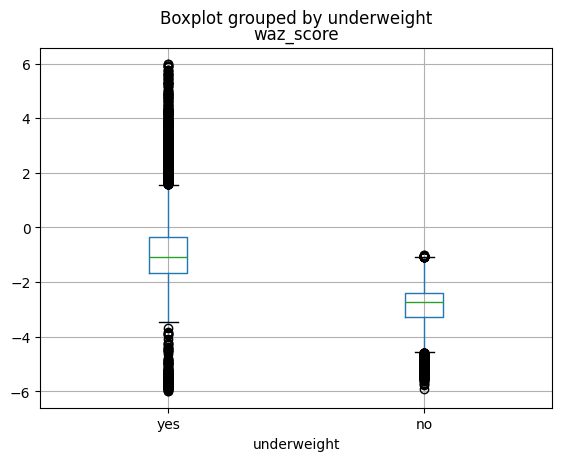

In [16]:
df.boxplot(column='waz_score', by='underweight')
plt.xticks([1, 2], ['yes', 'no'])
plt.savefig('screenshots/ss_bivariate/underweight_waz_bivariate_box.png')
plt.show()